<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fandresmj/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [4]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1250/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1250/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

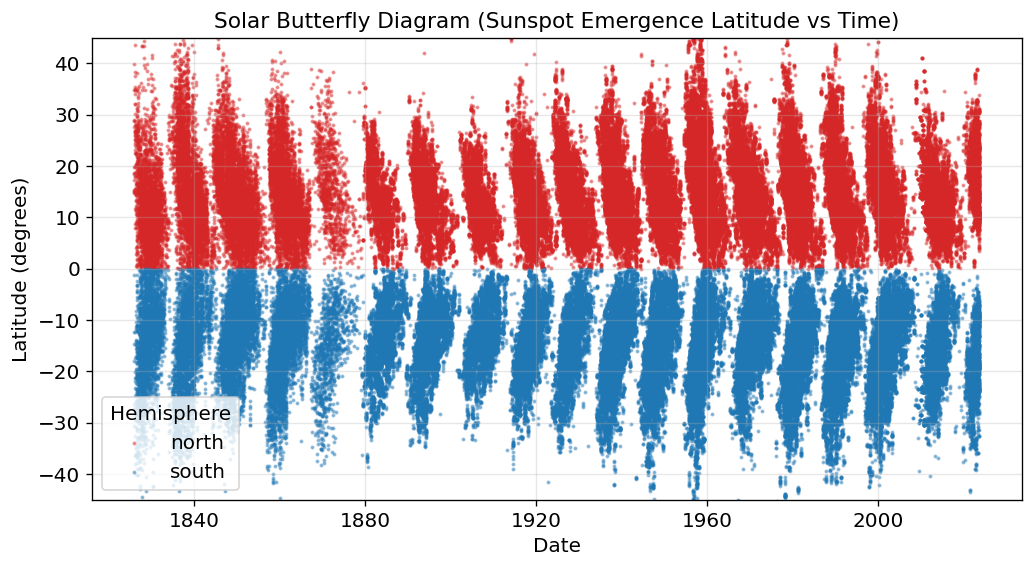

In [5]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


In [ ]:
# Your code here: Visualize a single solar cycle


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


In [ ]:
# Your code here: Calculate and plot mean latitudinal paths


## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*


# Task
Enhance the existing butterfly diagram by coloring each sunspot emergence point according to its `CYCLE` number, adding a colorbar to clarify the cycle mapping, and handling any missing `CYCLE` data by converting it to an appropriate numeric type.

## Prepare Cycle Data

### Subtask:
Inspect the `CYCLE` column for data types and missing values. Convert it to an appropriate numeric type and handle any `NaN` values.


**Reasoning**:
The first step is to inspect the `CYCLE` column to understand its current data type and the extent of missing values. This will inform the subsequent cleaning steps.



In [6]:
print(df['CYCLE'].dtype)
print(df['CYCLE'].isnull().sum())

float64
1574


**Reasoning**:
Based on the previous inspection, the `CYCLE` column is `float64` with `1574` missing values. To address this, I will fill the NaN values with 0 and then convert the column to an integer type as instructed.



In [7]:
df['CYCLE'].fillna(0, inplace=True)
df['CYCLE'] = df['CYCLE'].astype(int)

print(df['CYCLE'].dtype)
print(df['CYCLE'].isnull().sum())

int64
0


/tmp/ipykernel_1250/1466558136.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CYCLE'].fillna(0, inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` about using `inplace=True` with chained assignment, which may not modify the original DataFrame. To fix this, I will remove `inplace=True` and reassign the result of `fillna` back to the column to ensure the modification is applied correctly.



In [8]:
df['CYCLE'] = df['CYCLE'].fillna(0)
df['CYCLE'] = df['CYCLE'].astype(int)

print(df['CYCLE'].dtype)
print(df['CYCLE'].isnull().sum())

int64
0


## Plot Butterfly Diagram with Cycle Coloring

### Subtask:
Modify the existing plotting code to use the `CYCLE` column to determine the color of each sunspot emergence point, allowing for a visual distinction of sunspots belonging to different solar cycles.


**Reasoning**:
The subtask requires modifying the existing plotting code to color sunspot emergence points by their `CYCLE` number. This involves creating a scatter plot using `date` for the x-axis, `latitude` for the y-axis, and `CYCLE` for the color, along with adding a colorbar, title, and labels.



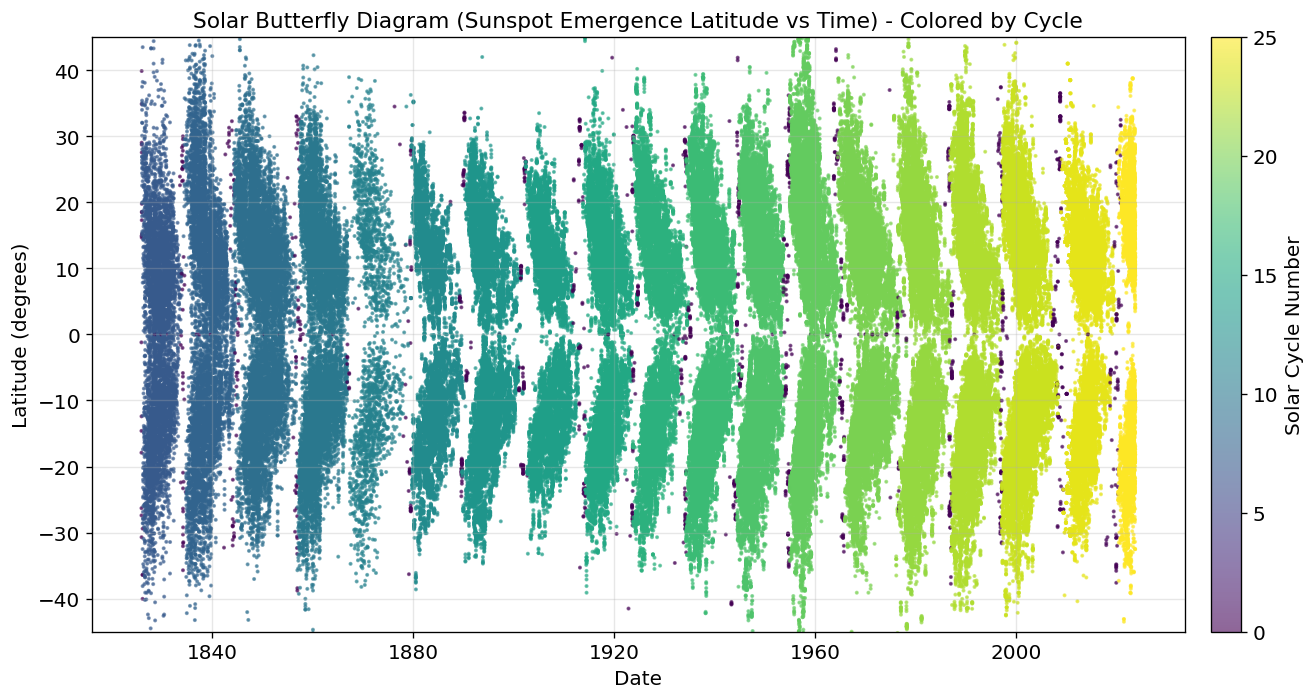

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Create the scatter plot, coloring by 'CYCLE'
scatter = ax.scatter(df['date'], df['latitude'], c=df['CYCLE'], cmap='viridis', s=2, alpha=0.6)

# Add a colorbar to indicate the cycle numbers
cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Solar Cycle Number')

ax.set_title('Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time) - Colored by Cycle')
ax.set_xlabel('Date')
ax.set_ylabel('Latitude (degrees)')
ax.set_ylim(-45, 45)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the updated visualization, explaining how the solar cycle information enhances the butterfly diagram.


## Summary:

### Q&A
The solar cycle information significantly enhances the butterfly diagram by providing a clear visual distinction between sunspots belonging to different solar cycles. By coloring each sunspot emergence point according to its `CYCLE` number, the diagram explicitly illustrates the progression and overlap of different solar cycles over time, making it easier to observe the temporal evolution and boundaries of each cycle. This visualization method clarifies the cyclical nature of sunspot activity, allowing for a more immediate understanding of the long-term patterns beyond just the latitude migration.

### Data Analysis Key Findings
*   Initially, the `CYCLE` column was of `float64` type and contained `1574` missing values.
*   Missing `CYCLE` values were filled with `0`, and the column was successfully converted to `int64` type, resulting in `0` missing values.
*   The enhanced butterfly diagram effectively visualizes sunspot emergence latitude against time, with each sunspot colored according to its solar cycle number.
*   A colorbar was successfully integrated into the plot, clearly mapping the color gradient to specific solar cycle numbers, thus improving the interpretability of the cycle distribution.

### Insights or Next Steps
*   The enhanced butterfly diagram, colored by solar cycle, provides a more granular understanding of sunspot evolution within and across cycles, allowing for visual identification of cycle boundaries and potential overlaps.
*   Further analysis could involve exploring the statistical distribution of sunspots within each cycle, or correlating cycle-specific sunspot activity with other solar phenomena.
